In [1]:
import glob
import numpy as np
import pandas as pd
import tables as tb

import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from matplotlib import cm

cmap = plt.get_cmap('viridis').copy()
cmap.set_under(color='white') 
plot_cmap = cm.get_cmap('turbo_r')

def lineal(x, a, b):
    return a*x + b

def in_range(x, rang):
    return (x > rang[0]) & (x < rang[1])

from scipy.optimize import curve_fit
from scipy.integrate import quad

def gauss(x, a, mu, sigma):
    return a * np.exp(-((x - mu) / sigma) ** 2 / 2)

def expon(x, m, c):
    return m *np.exp(-x/c)

def peak_fit(x, a, mu, sigma, m, c):
    return gauss(x, a, mu, sigma) + expon(x, m, c)

def fit_and_plot_peaks_resolution(data, fun, nbins, plotrange, fitrange, initial_params, bounds, title, density = True, plot = False):
    y, x = np.histogram(data, nbins, range = plotrange, density = density)

    total_counts = len(data)
    bin_width = x[1] - x[0]

    if density:
        yerr = np.sqrt(y) / (bin_width * total_counts)
    else:
        yerr = np.sqrt(y)
    
    # Prevent zero errors
    yerr[yerr == 0] = np.min(yerr[yerr > 0]) if np.any(yerr > 0) else 1.0
    
    # from the xbins we select the range to plot, otherwise things don't match
    fit_mask = (x > fitrange[0]) & (x < fitrange[1])
    fit_x, fit_y, fit_yerr = x[fit_mask], y[fit_mask[:-1]], yerr[fit_mask[:-1]]
    params, cov = curve_fit(fun, fit_x, fit_y, p0=initial_params, sigma=fit_yerr, bounds = bounds, maxfev = 2000, absolute_sigma = True)
    err = np.sqrt(np.diag(cov))
    a, mu, sigma, m, c = params[0], params[1], params[2], params[3], params[4]
    yfit = fun(fit_x, a, mu, sigma, m, c)

    R = 2 * np.sqrt(2 * np.log(2)) * sigma * 100 / mu
    sR = R * np.sqrt((err[2] / sigma) **2 + (err[1]/mu)**2)

    if plot:
        legend_string = r'$\mu={:.3f} \pm {:.3e}$'.format(mu, err[1]) + '\n' + \
                        r'$\sigma={:.3f} \pm {:.3e}$'.format(sigma, err[2]) + '\n' + \
                        r'R(%) = ${:.3f} \pm {:.3e}$'.format(R, sR)
        plt.hist(data, nbins, range = plotrange, histtype='step', density = density)
        plt.errorbar(0.5 * (x[:-1] + x[1:]), y, yerr=yerr, fmt = ' ', c='tab:blue', alpha = 0.5)
        plt.plot(fit_x, yfit, 'r-', label = legend_string)
        plt.legend()
        plt.xlabel('E (MeV)')
        if density:
            plt.ylabel('Probability density (1 / MeV)')
        else:
            plt.ylabel('Events')
        plt.title(title)
        plt.grid()
        plt.show()
    return [params, err], [R, sR]

def fit_whole_peaks(df, var, model, range, nbins, initial_params = None, bounds = ([0, 0, 0, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf, np.inf]), density = False, title = '', plot = False):
    data = df[in_range(df[var], range)][var]

    y, x = np.histogram(data, nbins)
    if initial_params is None:
        A0 = max(y) - min(y)
        mu0 = x[np.argmax(y)]

        half_max = np.max(y) / 2
        indices = np.where(y > half_max)[0]
        fwhm = x[indices[-1]] - x[indices[0]]

        sig0 = fwhm / (2 * np.sqrt(2 * np.log(2)))  # FWHM = 2.355 * sigma
        m0 = np.min(y)

        initial_params = [A0, mu0, sig0, m0, 1]

    par, res = fit_and_plot_peaks_resolution(data, 
                                            model,
                                            nbins, 
                                            range, 
                                            range, 
                                            initial_params, 
                                            bounds, 
                                            title, 
                                            density=density, 
                                            plot = plot)
    return par, res

In [2]:
run_numbers = [15589, 15590, 15591, 15592, 15593, 15594, 15596, 15597] #, 15604, 15605, 15607]

run_folder = 'HE_runs'
run_summary_name = 'run_cut_nmap_{}.h5'
wf_selection_name = 'sel_wf_{}.h5'

path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/{run_folder}/{run_number}/'


In [8]:
dst_summ, reco_summ, eff_summ = pd.DataFrame([]), pd.DataFrame([]), pd.DataFrame([])
for run_n in run_numbers:
    save_path_summary = path.format(run_folder = run_folder, run_number = run_n) + run_summary_name.format(run_n)
    run_dst  = pd.read_hdf(save_path_summary, 'DST/Events')
    run_dst['run_n'] = str(run_n)
    run_reco = pd.read_hdf(save_path_summary, 'RECO/Events_summary')
    eff = pd.read_hdf(save_path_summary, 'RUN/eff')
    eff['run_n'] = run_n

    dst_summ = dst_summ.append(run_dst)
    reco_summ = reco_summ.append(run_reco)
    eff_summ = eff_summ.append(eff)


In [9]:
reco_summ['total_energy'] = reco_summ['total_energy'] * 0.0415/8200
reco_summ['Ec_drop_in'] = reco_summ['Ec_drop_in'] * 0.0415/8200
reco_summ['Ec_drop_out'] = reco_summ['Ec_drop_out'] * 0.0415/8200

In [10]:
reco_summ = reco_summ.fillna({'Ec_drop_in': 0, 'Ec_drop_out':0})
reco_summ['total_energy_d'] = reco_summ['total_energy'] - reco_summ['Ec_drop_out']

In [11]:
nlines = len(run_numbers)

min_val, max_val = 0.08, 0.9  
plot_colors = [plot_cmap(min_val + (max_val - min_val) * i / (nlines - 1)) for i in range(nlines)]

### Efficiences

Text(0, 0.5, 'Eff (%)')

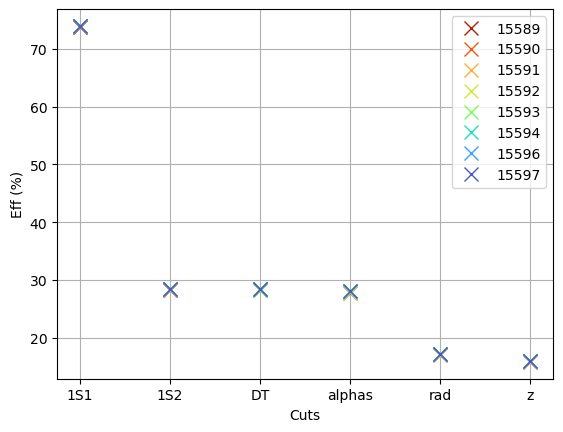

In [12]:
for run_n, c in zip(run_numbers, plot_colors):
    plt.plot(['1S1', '1S2', 'DT', 'alphas', 'rad', 'z'], (eff_summ[eff_summ.run_n == run_n][['1S1', '1S2', 'DT', 'alphas', 'rad', 'z']] / eff_summ[eff_summ.run_n == run_n][['total']].values).T * 100, 'x', color = c, markersize = 10, label = run_n)
plt.grid()
plt.legend()
plt.xlabel('Cuts')
plt.ylabel('Eff (%)')
# plt.yscale('log')

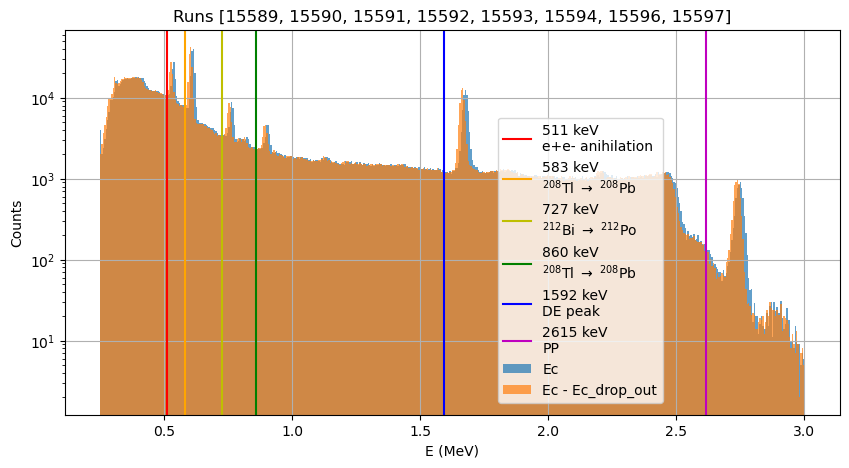

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(reco_summ.total_energy, 500, (0.25, 3), alpha = 0.7, label = 'Ec')
plt.hist(reco_summ.total_energy_d, 500, (0.25, 3), alpha = 0.7, label = 'Ec - Ec_drop_out')


plt.axvline(0.511, c = 'r', label = '511 keV\ne+e- anihilation')
plt.axvline(0.583, c = 'orange', label = '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(0.727, c = 'y', label = '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po')
plt.axvline(0.860, c = 'g', label = '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(1.592, c = 'b', label = '1592 keV\nDE peak')
plt.axvline(2.615, c = 'm', label = '2615 keV\nPP')
plt.grid()
plt.yscale('log')
plt.title('Runs {}'.format(run_numbers))
plt.xlabel('E (MeV)')
plt.ylabel('Counts')
plt.legend(loc = 'upper left', bbox_to_anchor = (0.55, 0.79))

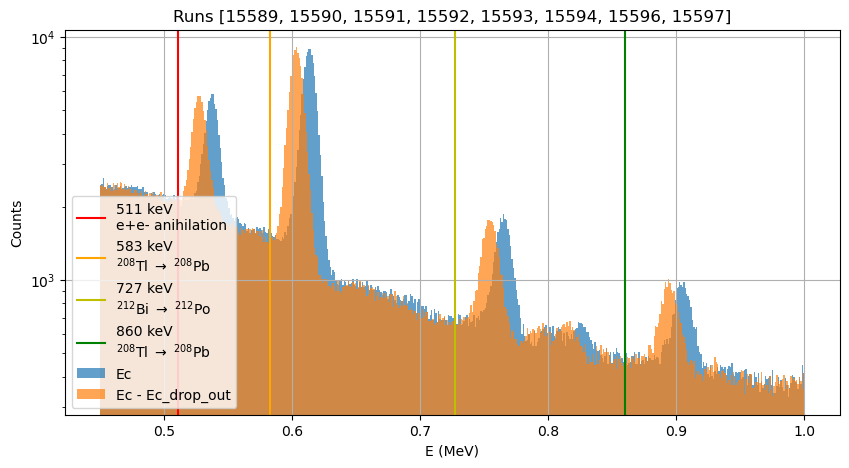

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(reco_summ.total_energy, 500, (0.45, 1), alpha = 0.7, label = 'Ec')
plt.hist(reco_summ.total_energy_d, 500, (0.45, 1), alpha = 0.7, label = 'Ec - Ec_drop_out')

plt.grid()
plt.yscale('log')
plt.axvline(0.511, c = 'r', label = '511 keV\ne+e- anihilation')
plt.axvline(0.583, c = 'orange', label = '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(0.727, c = 'y', label = '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po')
plt.axvline(0.860, c = 'g', label = '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.title('Runs {}'.format(run_numbers))
plt.xlabel('E (MeV)')
plt.ylabel('Counts')
plt.legend(loc = 'lower left')

### Energy scale

In [15]:
def get_peak_centers(run_numbers, reco_summ, variable, peak_ranges, npeaks = 4, plot = True):
    peak_nbins = [100, 100, 60, 40, 100, 20]
    peak_names  = ['e+e- anihilation (511 keV)', r'$^{208}$Tl $\rightarrow$ $^{208}$Pb (583 keV)', r'$^{212}$Bi $\rightarrow$ $^{212}$Po (727 keV)', r'$^{208}$Tl $\rightarrow$ $^{208}$Pb (860 keV)', '1592 keV\nDEP', '2615 keV\nPP']

    ranges = peak_ranges[:npeaks]
    nbins  = peak_nbins[:npeaks]
    names  = peak_names[:npeaks]
    
    meas_peaks = {}
    for run_n in run_numbers:
        run_reco = reco_summ[reco_summ.run_n == str(run_n)]
        meas_val, meas_err = [], []
        for rang, nbin, name in zip(ranges, nbins, names):
            par, res = fit_whole_peaks(run_reco, variable, peak_fit, rang, nbin, title = 'Run {} - '.format(run_n) + name, plot = plot)
            meas_val.append(par[0][1])
            meas_err.append(par[1][1])
        meas_peaks[run_n] = [meas_val, meas_err]
    return meas_peaks

In [16]:
peak_ranges = [(0.5, 0.58), (0.58, 0.65), (0.72, 0.81), (0.85, 0.95), (1.62, 1.75), (2.7, 2.8)]
peak_ranges_d = [(0.48, 0.56), (0.57, 0.64), (0.71, 0.80), (0.85, 0.95), (1.59, 1.72), (2.69, 2.79)]

In [17]:
meas_peaks = get_peak_centers(run_numbers, reco_summ, 'total_energy', peak_ranges, npeaks=6, plot = False)
meas_peaks_d = get_peak_centers(run_numbers, reco_summ, 'total_energy_d', peak_ranges_d, npeaks = 6, plot = False)

In [18]:
def plot_real_vs_meas_peaks(meas_peaks, run_numbers, plot_colors, npeak = 4):
    real_peaks = [0.511, 0.583, 0.727, 0.86, 1.592, 2.615]
    real_peaks = real_peaks[:npeak]
    for run_n, c in zip(run_numbers, plot_colors):
        if run_n not in meas_peaks.keys(): continue
        if len(meas_peaks[run_n][0]) == 0: continue
        m_ = np.array(meas_peaks[run_n][0])
        e_ = np.array(meas_peaks[run_n][1])
        r_ = np.array(real_peaks)
        plt.errorbar(r_, ((m_ - r_) / r_) * 100, yerr = e_ * 100, color = c, markersize = 10, label = run_n, marker = '.', capsize=2)
    plt.legend()
    plt.grid()
    plt.xlabel('Real peak energy (MeV)')
    plt.ylabel('(Measured - Real) / Real peak energy (%)')

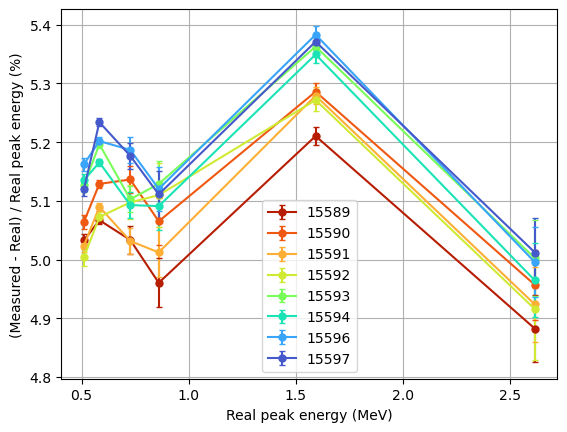

In [19]:
plot_real_vs_meas_peaks(meas_peaks, run_numbers, plot_colors, npeak = 6)

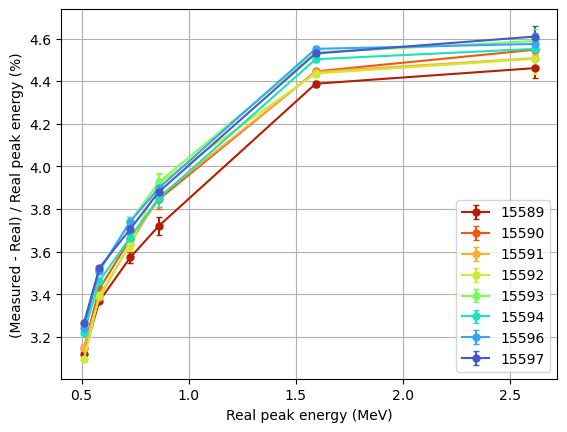

In [20]:
plot_real_vs_meas_peaks(meas_peaks_d, run_numbers, plot_colors, npeak = 6)

In [21]:
def energy_scale_fit(meas_peaks, run_numbers, plot_colors, npeaks = 4):
    real_peaks = [0.511, 0.583, 0.727, 0.86, 1.592, 2.615]
    color_peak = ['r', 'orange', 'y', 'g', 'b', 'm']
    real_peaks = real_peaks[:npeaks]
    color_peak = color_peak[:npeaks]
    
    parameters = {}
    for run_n, c in zip(run_numbers, plot_colors):
        if run_n not in meas_peaks.keys(): continue
        if len(meas_peaks[run_n][0]) == 0: continue
        for m_, r_, c_ in zip(meas_peaks[run_n][0], real_peaks, color_peak):
            plt.plot(m_, r_, '.', color = c_)
        par, err  = curve_fit(lineal, meas_peaks[run_n][0], real_peaks, p0 = (1, 0))
        plt.plot(meas_peaks[run_n][0], lineal(np.array(meas_peaks[run_n][0]), *par), color = c, label = str(run_n) + '\n m = {:.2e}'.format(par[0]) + '\n n = {:.2e}'.format(par[1]))
        parameters[run_n] = par
    plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5))
    plt.grid()
    plt.xlabel('Measured peak energy (MeV)')
    plt.ylabel('Real peak energy (MeV)')
    return parameters

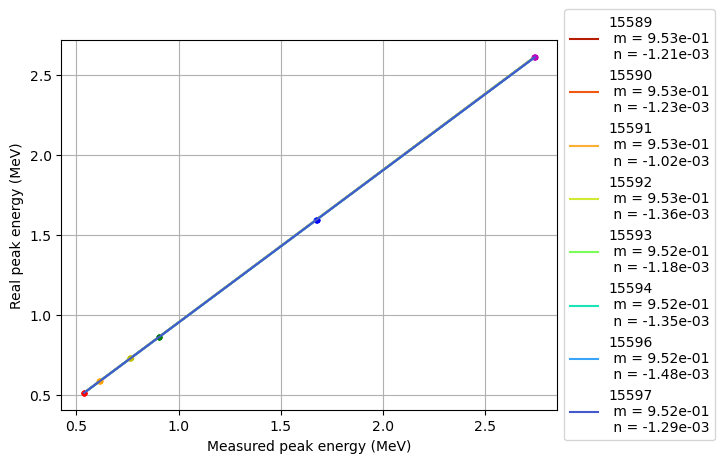

In [22]:
param = energy_scale_fit(meas_peaks, run_numbers, plot_colors, npeaks = 6)

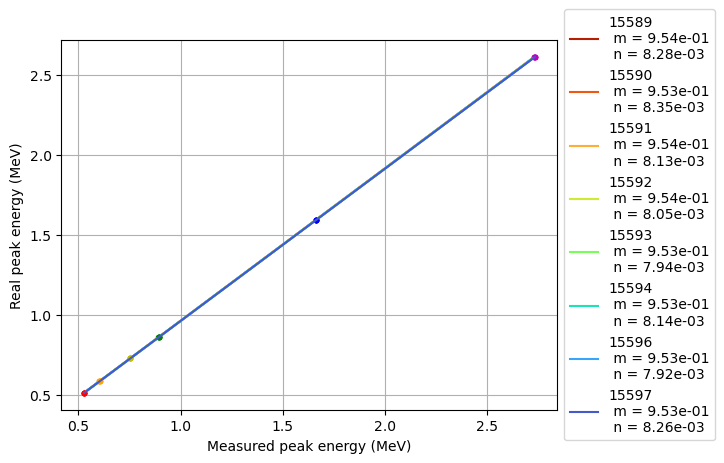

In [23]:
param_d = energy_scale_fit(meas_peaks_d, run_numbers, plot_colors, npeaks = 6)

In [24]:
reco_summ['E_shifted']   = reco_summ['total_energy'] * reco_summ['run_n'].map(lambda r: param[int(r)][0]) + reco_summ['run_n'].map(lambda r: param[int(r)][1])
reco_summ['E_shifted_d'] = reco_summ['total_energy_d'] * reco_summ['run_n'].map(lambda r: param_d[int(r)][0]) + reco_summ['run_n'].map(lambda r: param_d[int(r)][1])

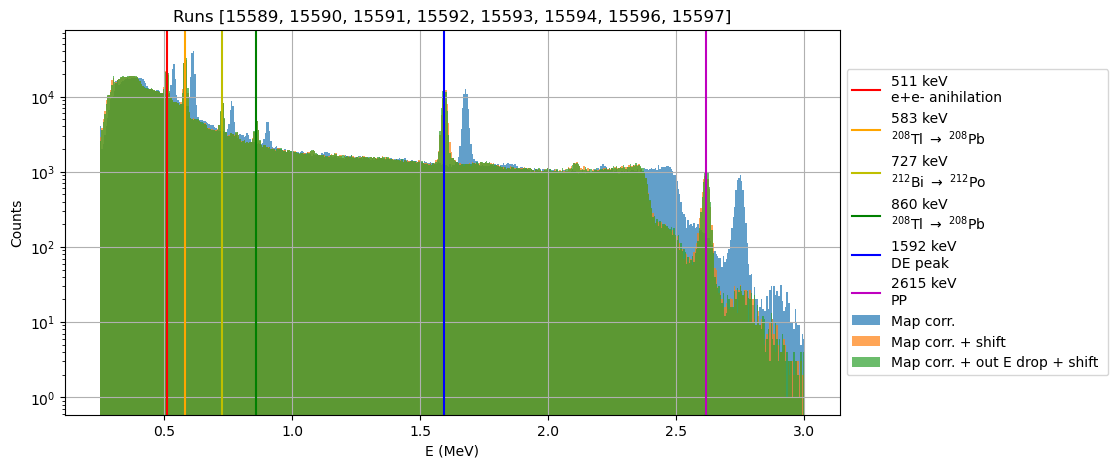

In [25]:
plt.figure(figsize=(10, 5))
plt.hist(reco_summ.total_energy, 500, (0.25, 3), alpha = 0.7, label = 'Map corr.')
plt.hist(reco_summ.E_shifted, 500, (0.25, 3), alpha = 0.7, label = 'Map corr. + shift')
plt.hist(reco_summ.E_shifted_d, 500, (0.25, 3), alpha = 0.7, label = 'Map corr. + out E drop + shift ')

plt.grid()
plt.yscale('log')
plt.axvline(0.511, c = 'r', label = '511 keV\ne+e- anihilation')
plt.axvline(0.583, c = 'orange', label = '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(0.727, c = 'y', label = '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po')
plt.axvline(0.860, c = 'g', label = '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(1.592, c = 'b', label = '1592 keV\nDE peak')
plt.axvline(2.615, c = 'm', label = '2615 keV\nPP')
plt.title('Runs {}'.format(run_numbers))
plt.xlabel('E (MeV)')
plt.ylabel('Counts')
plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5))

### Peak deviation

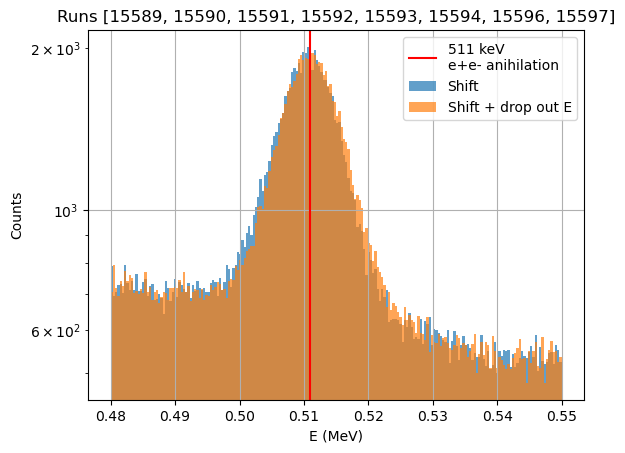

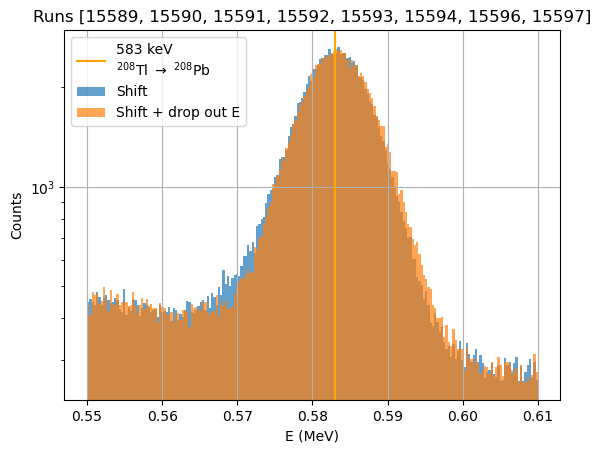

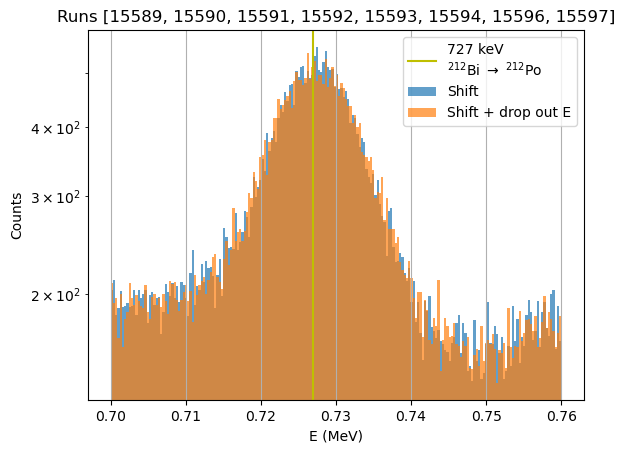

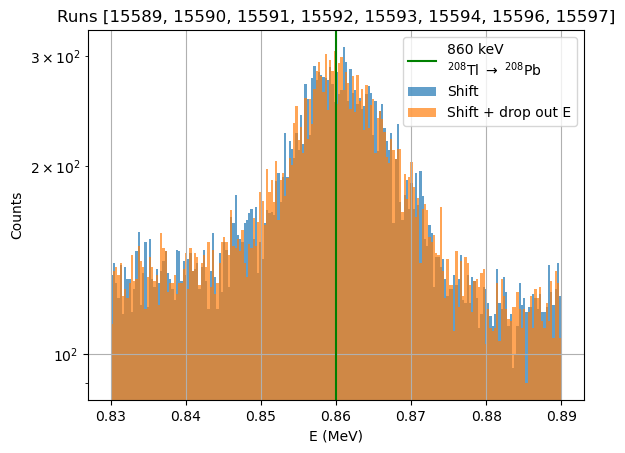

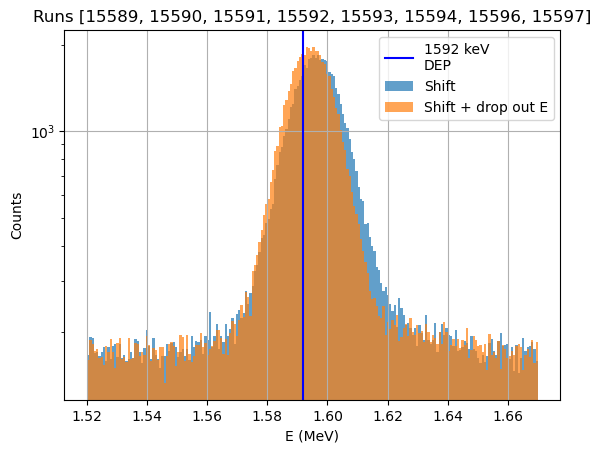

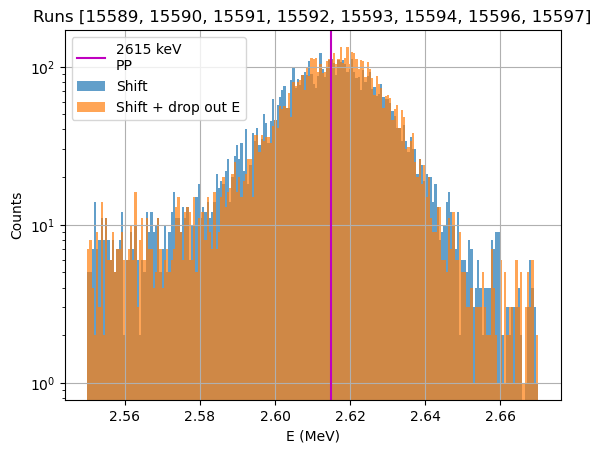

In [26]:
all_peak_ranges_shifted = [(0.48, 0.55), (0.55, 0.61), (0.7, 0.76), (0.83, 0.89), (1.52, 1.67), (2.55, 2.67)]
all_real_peaks = [0.511, 0.583, 0.727, 0.86, 1.592, 2.615]
all_peak_colors = ['r', 'orange', 'y', 'g', 'b', 'm']
all_peak_names  = ['511 keV\ne+e- anihilation', '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb', '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po', '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb', '1592 keV\nDEP', '2615 keV\nPP']


for rang, peak, lab, col in zip(all_peak_ranges_shifted, all_real_peaks, all_peak_names, all_peak_colors):
    plt.figure()
    plt.hist(reco_summ.E_shifted, 200, rang, alpha = 0.7, label = 'Shift')
    plt.hist(reco_summ.E_shifted_d, 200, rang, alpha = 0.7, label = 'Shift + drop out E')
    plt.axvline(peak, c = col, label = lab)
    plt.grid()
    plt.yscale('log')
    plt.title('Runs {}'.format(run_numbers))
    plt.xlabel('E (MeV)')
    plt.ylabel('Counts')
    plt.legend()

In [27]:
peak_ranges_shift = [(0.48, 0.55), (0.55, 0.61), (0.7, 0.76), (0.83, 0.89), (1.52, 1.67), (2.55, 2.67)]

In [28]:
# I want to check always the 6 peaks, but with 4 and 6 peaks param correction
meas_peaks_shift = get_peak_centers(run_numbers, reco_summ, 'E_shifted', peak_ranges_shift, npeaks=6, plot = False)
meas_peaks_shift_d = get_peak_centers(run_numbers, reco_summ, 'E_shifted_d', peak_ranges_shift, npeaks=6, plot = False)

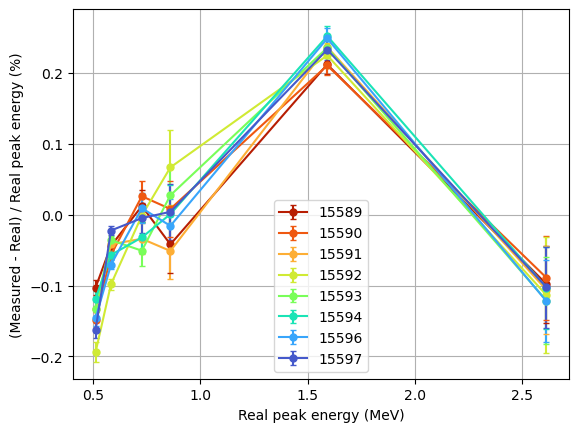

In [29]:
plot_real_vs_meas_peaks(meas_peaks_shift, run_numbers, plot_colors, npeak=6)

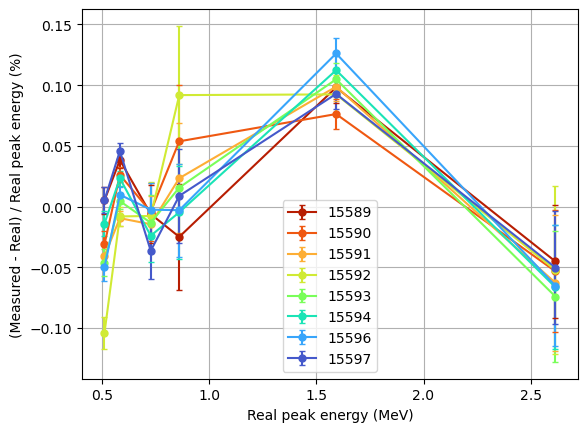

In [30]:
plot_real_vs_meas_peaks(meas_peaks_shift_d, run_numbers, plot_colors, npeak=6)

### E resolution (with no corrections + selected range)

In [79]:
def extrapol_energy(R_0, E_0, s_R_0, s_E_0, E_1):
    R_1 = R_0 * np.sqrt(E_0 / E_1)
    s_R_1 = np.sqrt((E_0 / E_1) * s_R_0 **2 + (1/4) * R_0 **2 * (E_1 / E_0) * s_E_0 ** 2)
    return R_1, s_R_1

In [80]:
ene_var_corr = 'E_shifted_d'

fit_ranges = [(0.495, 0.527), (0.565, 0.603), (0.702, 0.752), (0.83, 0.89),  (1.57, 1.62), (2.58, 2.65)]
fit_nbins  = [100, 100, 100, 100, 120, 60]
fit_names  = ['511', '583', '727', '860', '1592', '2615']

In [81]:
peaks = []
resol = []
for rng, nbin, name in zip(fit_ranges, fit_nbins, fit_names):
    par, R = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, rng, nbin, title = 'Run {} - '.format(run_numbers) + name, plot = False)
    plt.show()
    peaks.append([par[0][1], par[1][1]])
    resol.append(R)
for R, name in zip(resol, fit_names):
    print('Energy resolution {}: {:.3f} ± {:.3f} %'.format(name, R[0], R[1]))

Energy resolution 511: 2.186 ± 0.027 %
Energy resolution 583: 2.136 ± 0.012 %
Energy resolution 727: 1.970 ± 0.032 %
Energy resolution 860: 1.802 ± 0.050 %
Energy resolution 1592: 1.185 ± 0.010 %
Energy resolution 2615: 0.972 ± 0.023 %


Text(0, 0.5, 'R$^2$ (%FWHM)$^2$')

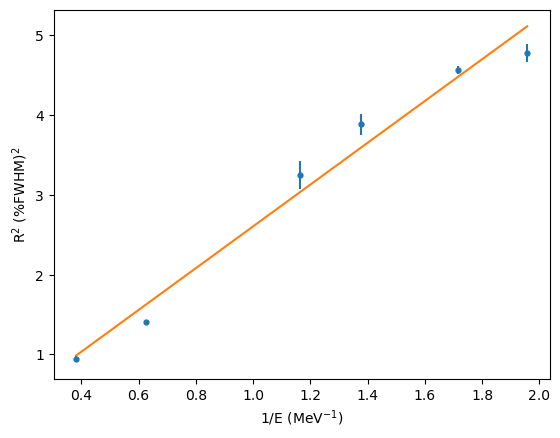

In [74]:
e_inv = 1 / (np.array(peaks)[:, 0])
r_sq = np.array(resol)[:, 0]**2
r_sq_s = 2 * np.array(resol)[:, 0] * np.array(resol)[:, 1]


plt.errorbar(e_inv, r_sq, yerr= r_sq_s, ls = 'none',  marker = '.', markersize = 7)

p, e = curve_fit(lineal, e_inv, r_sq, p0 = (1, 0))
plt.plot(e_inv, lineal(e_inv, *p))

plt.xlabel('1/E (MeV$^{-1}$)')
plt.ylabel('R$^2$ (%FWHM)$^2$')

In [75]:
E_1 = 2.615
extrapol, extrapol_s = extrapol_energy(np.array(resol)[:, 0], np.array(peaks)[:, 0], np.array(resol)[:, 1], np.array(peaks)[:, 1], E_1)

In [76]:
extrapol = np.array(resol)[:, 0] * np.sqrt(np.array(peaks)[:, 0] / 2.615)

for ext, ext_s, name in zip(extrapol, extrapol_s, fit_names):
    print('Extrapolated E res {} to {}: {:.3f} ± {:.3f} %'.format(name, E_1, ext, ext_s))

Extrapolated E res 511 to 2.615: 0.966 ± 0.012 %
Extrapolated E res 583 to 2.615: 1.009 ± 0.005 %
Extrapolated E res 727 to 2.615: 1.039 ± 0.017 %
Extrapolated E res 860 to 2.615: 1.033 ± 0.029 %
Extrapolated E res 1592 to 2.615: 0.925 ± 0.008 %
Extrapolated E res 2615 to 2.615: 0.973 ± 0.023 %


Text(0, 0.5, 'Extrapol R to 2.615 MeV (%)')

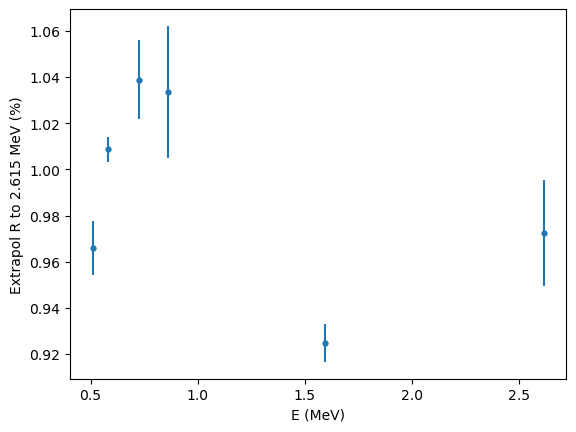

In [77]:
plt.errorbar(np.array(peaks)[:, 0], extrapol, yerr = extrapol_s, ls = 'none', marker = '.', markersize = 7)
plt.xlabel('E (MeV)')
plt.ylabel('Extrapol R to 2.615 MeV (%)')

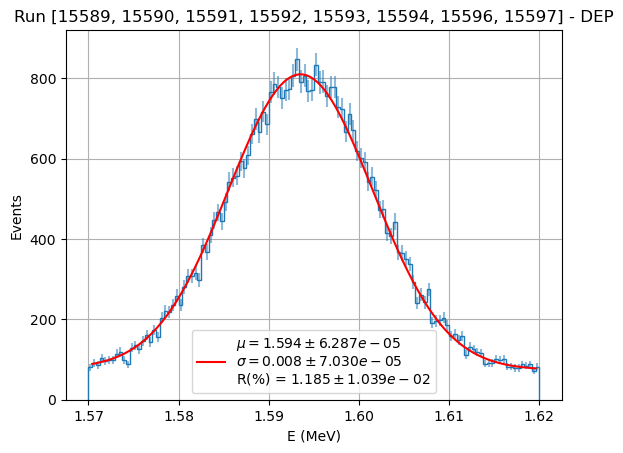

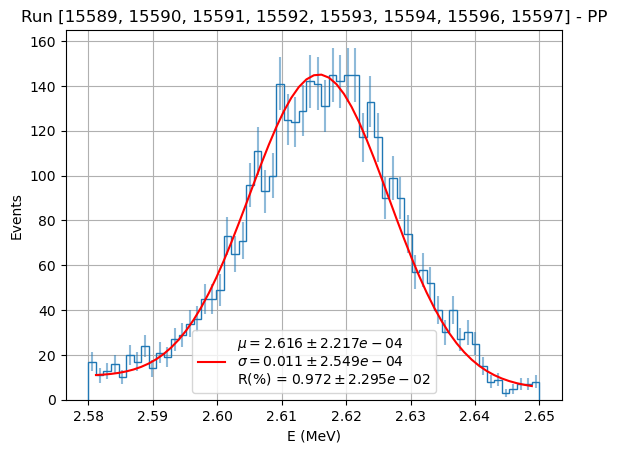

Energy resolution DEP: 1.185 ± 0.010 %
Energy resolution PP: 0.972 ± 0.023 %


In [45]:
_, r_dep = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, dep_range, dep_nbins, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_pp  = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, pp_range, pp_nbins, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
print('Energy resolution DEP: {:.3f} ± {:.3f} %'.format(r_dep[0], r_dep[1]))
print('Energy resolution PP: {:.3f} ± {:.3f} %'.format(r_pp[0], r_pp[1]))

### Dependencies of E with variables

In [46]:
from invisible_cities.core.fit_functions import expo
from invisible_cities.core.fit_functions import profileX
from scipy.optimize                      import curve_fit

def quad(x, a, b, c):
    return a*x**2 + b*x + c


def plot_profile(df, xvar, yvar, fitfun = None, initial_values = None, std = False, fitbins = 20, plotbins = (50, 50), fitrange = (None, None), plotrange = (None, None), axlabel = ['', ''], units = ['mm', 'MeV'], title = '', cmap = 'viridis'):
    x, y, sy = profileX(df[xvar], df[yvar], std=std, nbins = fitbins, xrange = fitrange[0], yrange=fitrange[1])
    par = None
    if fitfun:
        par, err  = curve_fit(fitfun, x, y, sigma=sy, p0 = initial_values)
        label_lines = [f'$x_{{{i}}}$ = {p:.2e} ' + r'$\mathrm{' + units[1] + r'}/\mathrm{' + units[0] + r'}^{{' + f'{i}' + '}}$' for i, p in enumerate(par[::-1])]
        label = "\n".join(label_lines)

        plt.plot(x, fitfun(x, *par), 'r-', label = label)
    plt.errorbar(x = x, y = y, yerr = sy, fmt = 'r.')

    plt.hist2d(df[xvar], df[yvar], bins = plotbins, range = plotrange, cmap = cmap, vmin = 1e-3)
    plt.xlabel(axlabel[0] + ' ({})'.format(units[0]))
    plt.ylabel(axlabel[1] + ' ({})'.format(units[1]))
    plt.legend()
    plt.title(title)
    plt.show()
    if type(par) != None: 
        return par

In [47]:
reco_summ = reco_summ.merge(dst_summ[['event', 'run_n', 'S1e', 'S2e']], on = ['event', 'run_n'])

### Correct dependencies

Right now, we will only correct in **Z_bary**:
* **$\Delta$ Z** was solved for DEP after the dropping out hits energy correction, not quite for PP but its correction doesn't affect a lot
* **S1e** gets mainly solved after correcting **Z_bary**, and for the PP makes resolution worse.

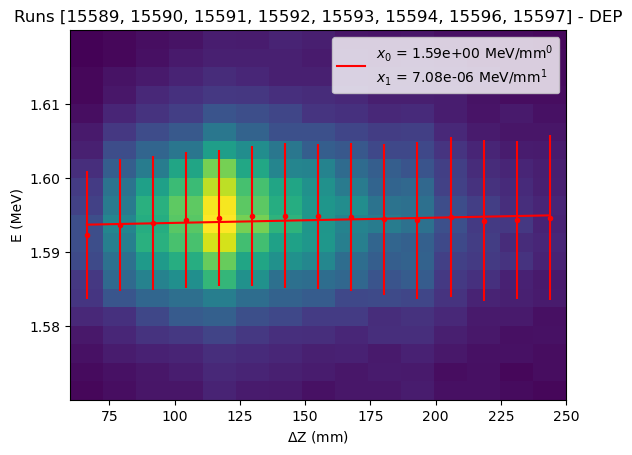

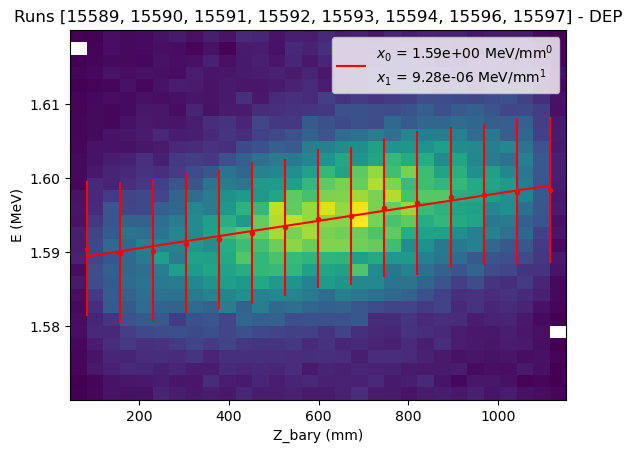

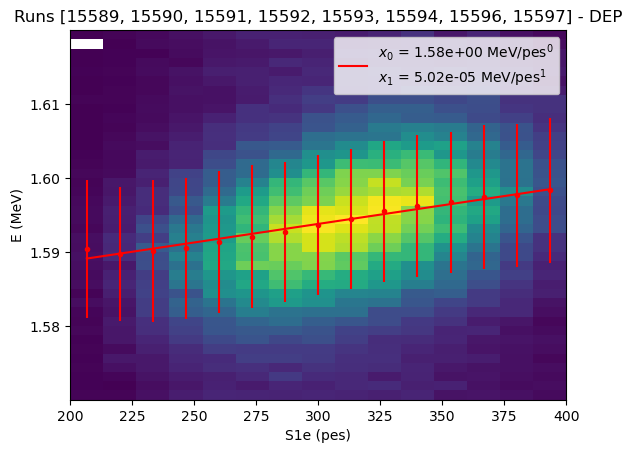

array([5.01927319e-05, 1.57873161e+00])

In [52]:
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'S1e', ene_var_corr, fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((200, 400), None), plotrange=((200, 400), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)


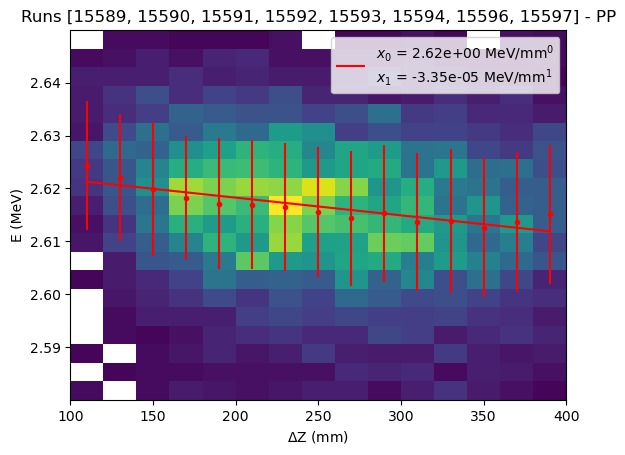

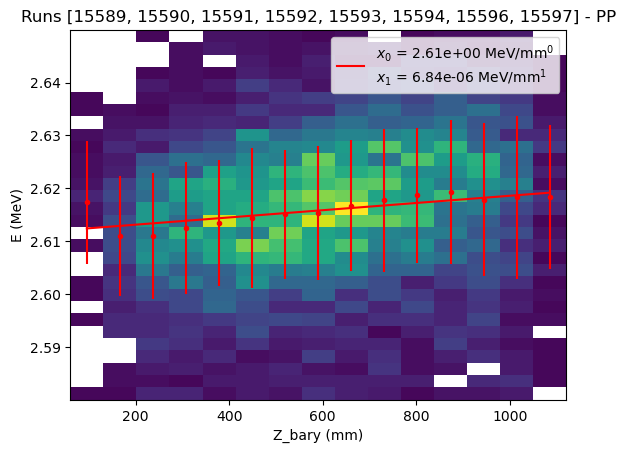

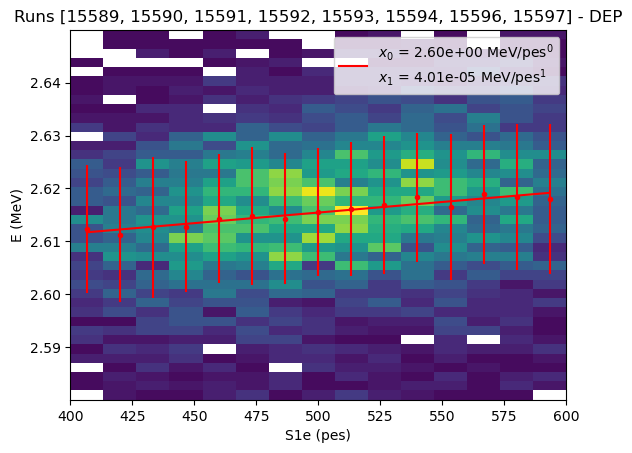

array([4.00506286e-05, 2.59540046e+00])

In [53]:
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr],  pp_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=((100, 400), None), plotrange=((100, 400), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'S1e', ene_var_corr, fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((400, 600), None), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

**Z_bary**

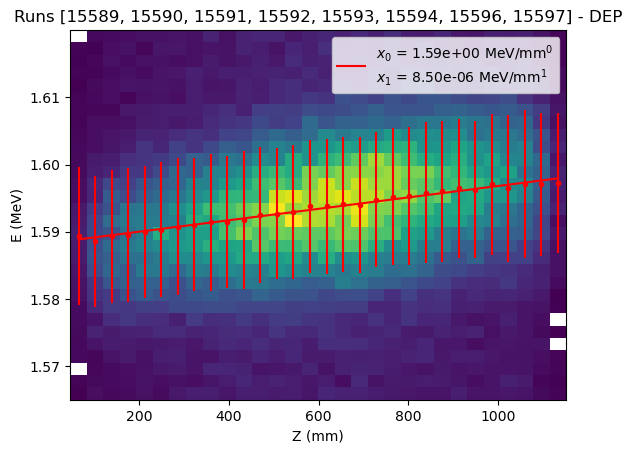

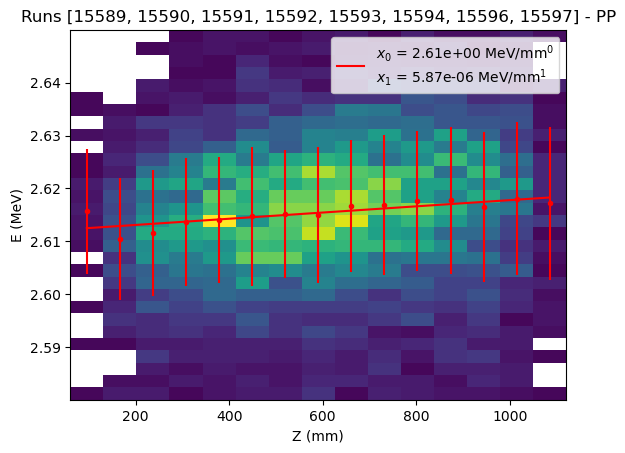

In [31]:
par_DEP_Z = plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=30, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = ['Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
par_PP_Z = plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = ['Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)


In [32]:
dp_correct = reco_summ[in_range(reco_summ[ene_var_corr], dep_range)].copy()
pp_correct = reco_summ[in_range(reco_summ[ene_var_corr], pp_range)].copy()

In [33]:
dp_correct['E_Z'] =  dp_correct[ene_var_corr] / (1 + (par_DEP_Z[0] / par_DEP_Z[1]) * dp_correct.Z_bary)
pp_correct['E_Z'] =  pp_correct[ene_var_corr] / (1 + (par_PP_Z[0] / par_PP_Z[1]) * pp_correct.Z_bary)

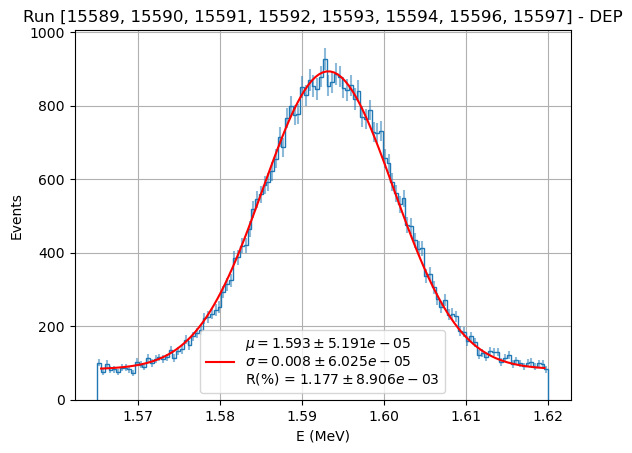

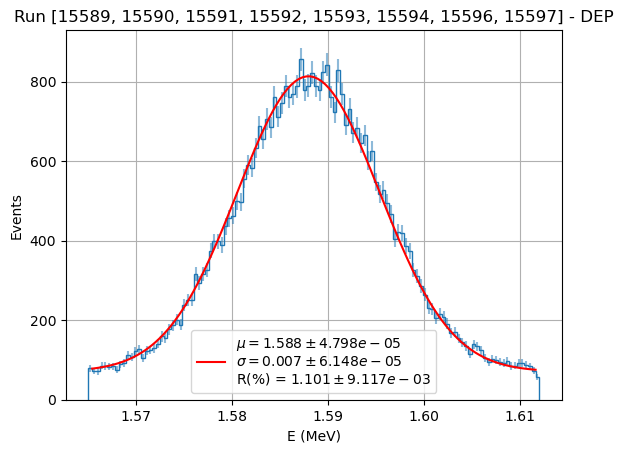

Energy resolution DEP: 1.177 ± 0.009 %
Energy resolution DEP (dZ corr): 1.101 ± 0.009 %


In [34]:
_, r_dep = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, dep_range, 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_dep_dZ = fit_whole_peaks(dp_correct[dp_correct.Rmax < 400], 'E_Z', peak_fit, (1.565, 1.612), 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()

print('Energy resolution DEP: {:.3f} ± {:.3f} %'.format(r_dep[0], r_dep[1]))
print('Energy resolution DEP (dZ corr): {:.3f} ± {:.3f} %'.format(r_dep_dZ[0], r_dep_dZ[1]))


In [36]:
pp_range

(2.58, 2.65)

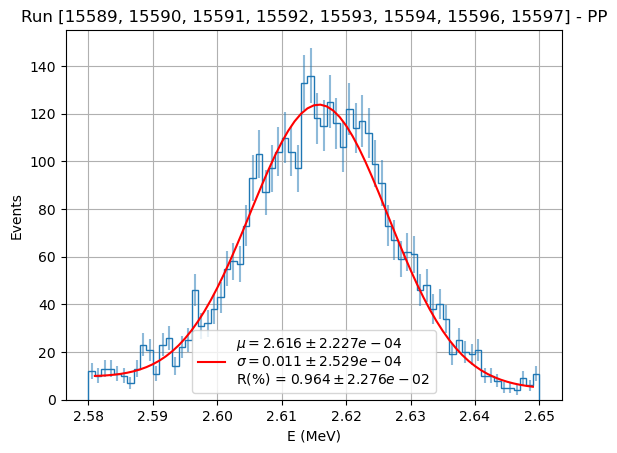

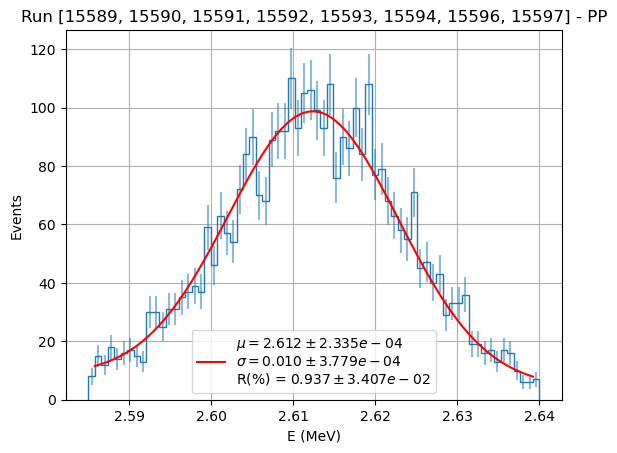

Energy resolution PP: 0.964 ± 0.023 %
Energy resolution PP (dZ corr): 0.937 ± 0.034 %


In [41]:
_, r_pp = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, pp_range, 70, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
_, r_pp_dZ = fit_whole_peaks(pp_correct[pp_correct.Rmax < 400], 'E_Z', peak_fit, (2.585, 2.64), 70, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()


print('Energy resolution PP: {:.3f} ± {:.3f} %'.format(r_pp[0], r_pp[1]))
print('Energy resolution PP (dZ corr): {:.3f} ± {:.3f} %'.format(r_pp_dZ[0], r_pp_dZ[1]))

## PARA EL PP, CORREGIR SOLO Z SIN HABER CORREGIDO ANTES DELTAZ PARECE QUE NO FUNCIONA MUY BIEN...

## Quizas tengo que ampliar el rango sobre el que corrijo un poco, para que no se me apelotonen eventos a un lado del pico?? o algo asin...

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Example data (replace with your real data)
df = reco_summ[in_range(reco_summ.E_shifted, 1.5, 1.7) & in_range(reco_summ.dZ, 0, 500)]

# Set Z bin edges
plot_var = 'E_shifted'
var = 'dZ'
num_bins = 20
z_bins = np.linspace(df[var].min(), df[var].max(), num_bins + 1)

# Create a slider for selecting Z bin index
z_bin_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(z_bins) - 2,
    step=1,
    description='Z bin:',
    continuous_update=True
)

# Output widget for plot
out = widgets.Output()

def update_plot(change):
    with out:
        clear_output(wait=True)
        
        # Get current Z bin range
        bin_idx = z_bin_slider.value
        z_min = z_bins[bin_idx]
        z_max = z_bins[bin_idx + 1]

        # Filter data for current Z bin
        mask = (df[var] >= z_min) & (df[var] < z_max)
        e_data = df.loc[mask, plot_var]

        # Compute histogram of E
        counts, edges = np.histogram(e_data, bins=100)

        # Plot
        plt.figure(figsize=(6, 4))
        plt.bar(edges[:-1], counts, width=np.diff(edges), edgecolor='black', align='edge')
        plt.title(f'Histogram of E for Z in [{z_min:.2f}, {z_max:.2f}]')
        plt.xlabel('E')
        plt.ylabel('Count')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Attach callback
z_bin_slider.observe(update_plot, names='value')

# Display
# display(z_bin_slider)
# update_plot(None)
# display(out)

update_plot(None) 
display(out, z_bin_slider)


Output()

IntSlider(value=0, description='Z bin:', max=19)

## Contar hits scatter

Necesito mirar cuántos hits estamos eliminando, cuanto contribuyen a la energía, etc, etc.. Para eso, hay que cambiar cositas digo yo

In [52]:
from sklearn.neighbors import NearestNeighbors

from   typing      import List
from   typing      import Callable

from invisible_cities.reco.corrections import read_maps, apply_all_correction
from invisible_cities.types.symbols import NormStrategy

In [53]:
def drop_isolated_clusters(distance: List[float] = [16., 16., 4.], nhit: int = 3,
                           variables: List[str] = []) -> Callable:
    '''
    If len(distance) == 2, it will perform on X, Y
    If len(distance) == 3, it will perform on X, Y, Z
    '''
    ndim = len(distance)
    dist = np.sqrt(ndim)

    def drop(df: pd.DataFrame) -> pd.DataFrame:
        if len(df) == 0:
            return df
        coords = []

        coords.append(df.X.values / distance[0])
        coords.append(df.Y.values / distance[1])

        if ndim == 3:
            coords.append(df.Z.values / distance[2])

        coords = np.column_stack(coords)

        try:
            nbrs = NearestNeighbors(radius=dist, algorithm='ball_tree').fit(coords)
            neighbors = nbrs.radius_neighbors(coords, return_distance=False)
            mask = np.array([len(neigh) > nhit for neigh in neighbors])
        except Exception as e:
            print(f"Error in NearestNeighbors: {{e}}")
            return df.iloc[:0]  # fallback: return empty

        pass_df = df.loc[mask].copy()

        if not pass_df.empty and variables:
            with np.errstate(divide='ignore', invalid='ignore'):
                columns = pass_df.loc[:, variables]
                scale = df[variables].sum().values / columns.sum().values
                columns *= scale
                pass_df.loc[:, variables] = columns

        return pass_df
    return drop



In [54]:
map_path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/new_HE_runs/rough_geometry_map_v2.h5' 
# Energy correction
maps = read_maps(map_path)

corr_fun  = apply_all_correction(maps
                                 , apply_temp = False
                                 , norm_strat = NormStrategy.kr)
# Cluster dropping
dist = [16., 16., 4.]
dropper = drop_isolated_clusters(distance = dist, nhit = 3, variables = ['Ec'])

In [55]:
def correct_and_drop(df, corr_fun, dropper):
    factor = corr_fun(df.X, df.Y, df.Z, df.time)
    df['Ec'] = df.E * factor
    #correct energy in the borders (for NaN hits)
    factor_border = corr_fun([479],[0],[0],[1])
    df["Ec_border"] = df.E * factor_border
    # add the latter energy
    df["Ec"] = df["Ec"].fillna(df["Ec_border"])

    #surviving hits after applying dropper function (they have the energy changed)
    df_surv = df.groupby(['event', 'npeak'], group_keys=False).apply(dropper)

    # dropped hits after the dropper (but with original energy)
    df_dropped = df.reset_index(drop=True).merge(df_surv.drop(columns = 'Ec').reset_index(drop=True), how='outer', indicator=True).query('_merge == "left_only"').drop(columns='_merge')
    # non dropped hits after the dropper (but with original energy)
    df_nondrop = df.reset_index(drop=True).merge(df_surv.drop(columns = 'Ec').reset_index(drop=True), how='outer', indicator=True).query('_merge == "both"').drop(columns='_merge')
    return df_surv, df_dropped, df_nondrop

In [56]:
run_number = 15589
data_path = '/mnt/netapp1/Store_next_data/NEXT100/data/{run_number}'.format(run_number = run_number) + '/*/*/*/*/*/*/'
files = sorted(glob.glob(data_path + '/*/*'), key=lambda x: (x.split('/')[-2], int(x.split('/')[-1].split('_')[2])))

file_name = '/{ldc_n}/run_{run_n}_{file_n}_{ldc_n}_*.h5'

wf_sel = pd.read_hdf(path.format(run_folder = run_folder, run_number = run_number) + wf_selection_name.format(run_number), 'RUN/Selected_events')

In [75]:
# savepath = path.format(run_folder = run_folder, run_number = run_number) + 'DEP_events_run_{rn}.txt'.format(rn = run_number)

# dep_ev_numbers = sorted(wf_sel[(wf_sel.total_energy > 1) & (wf_sel.total_energy < 2)].event.values)
# with open(savepath, "w") as file:
#     for number in dep_ev_numbers:
#         file.write(f"{number}\n")

In [71]:
wf_sel

,event,run_n,file_n,ldc_n,total_energy
0,25,15589,0000,ldc4,0.615760
3,277,15589,0000,ldc4,0.577600
7,655,15589,0000,ldc4,1.607510
3,970,15589,0001,ldc4,1.684617
4,1047,15589,0001,ldc4,1.700429
...,...,...,...,...,...
9,3843721,15589,5389,ldc7,0.573259
10,3844946,15589,5391,ldc7,0.613350
3,3846577,15589,5394,ldc7,0.608374
6,3846843,15589,5394,ldc7,0.621778


In [ ]:
df

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,13605,1.751991e+09,9,2.203595,66.265744,1,-173.625,-139.825,0.0,0.0,568.706563,7.200931,9.281789,-1.0,0.000047,-1,-1.0
1,13605,1.751991e+09,9,2.203595,66.265744,1,-373.775,-109.225,0.0,0.0,575.991313,7.289055,7.584962,-1.0,0.000042,-1,-1.0
2,13605,1.751991e+09,9,2.203595,66.265744,1,304.425,384.375,0.0,0.0,575.991313,7.423349,7.724708,-1.0,0.000117,-1,-1.0
3,13605,1.751991e+09,9,2.203595,66.265744,1,-3.575,199.275,0.0,0.0,588.301438,7.471891,1061.695827,-1.0,0.005501,-1,-1.0
4,13605,1.751991e+09,9,2.203595,66.265744,1,-34.675,214.825,0.0,0.0,592.051438,9.134922,159.171542,-1.0,0.000809,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30666,14354,1.751991e+09,30,142.057461,113.666961,1,319.975,229.875,0.0,0.0,567.664125,9.100561,277.512511,-1.0,0.001562,-1,-1.0
30667,14354,1.751991e+09,30,142.057461,113.666961,1,-65.775,-16.425,0.0,0.0,591.928000,7.276019,239.119474,-1.0,0.001218,-1,-1.0
30668,14354,1.751991e+09,30,142.057461,113.666961,1,304.425,431.025,0.0,0.0,591.928000,7.051032,231.725504,-1.0,NaN,-1,-1.0
30669,14354,1.751991e+09,30,142.057461,113.666961,1,-3.575,291.575,0.0,0.0,603.904875,8.445415,95.369649,-1.0,0.000510,-1,-1.0


In [79]:
pd.read_hdf(f[0], 'DST/Events')

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Nsipm,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms
0,13605,1.751991e+09,0,0,2,2,725.0,98.363991,610.778259,174100.0,...,1948,657.377686,657.377686,24.738549,2.203594,66.265743,66.302372,1.537555,236.368256,249.035801
1,13605,1.751991e+09,0,1,2,2,725.0,98.363991,610.778259,174100.0,...,3525,1238.384521,1238.384521,41.798980,52.859419,-111.682592,123.560185,-1.128736,202.100624,232.981129
2,13605,1.751991e+09,1,0,2,2,800.0,2.626363,45.556355,843475.0,...,1948,-11.997375,-11.997375,24.738549,2.203594,66.265743,66.302372,1.537555,236.368256,249.035801
3,13605,1.751991e+09,1,1,2,2,800.0,2.626363,45.556355,843475.0,...,3525,569.009521,569.009521,41.798980,52.859419,-111.682592,123.560185,-1.128736,202.100624,232.981129
4,13619,1.751991e+09,0,0,1,2,350.0,29.002560,166.324310,673650.0,...,2858,733.827271,733.827271,20.367145,125.881978,117.213152,172.003475,0.749753,241.520297,227.032694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,14256,1.751991e+09,1,1,2,3,200.0,6.992740,51.157097,1099900.0,...,3534,308.589142,308.589142,58.919535,62.295812,-61.248479,87.362145,-0.776921,227.254434,232.446112
68,14256,1.751991e+09,1,2,2,3,200.0,6.992740,51.157097,1099900.0,...,2537,1100.587524,1100.587524,9.533177,-43.782780,-10.473640,45.018096,-2.906787,269.965640,249.807699
69,14270,1.751991e+09,0,0,1,1,500.0,8.773518,47.533588,1171400.0,...,2775,234.082138,234.082138,8.320681,56.806820,-1.473056,56.825916,-0.025925,243.212199,227.288189
70,14354,1.751991e+09,0,0,1,2,650.0,12.439312,77.377838,863000.0,...,2053,-225.496201,-225.496201,12.778306,15.821554,10.450631,18.961467,0.583743,269.234654,252.239600


655 ldc4


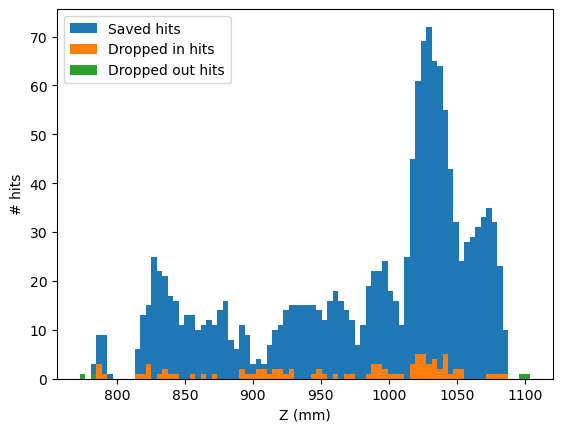

1.6075103036203509
970 ldc4


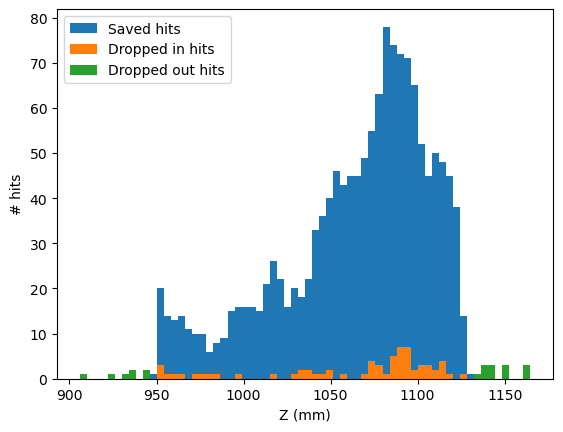

1.6846171946126343
1047 ldc4


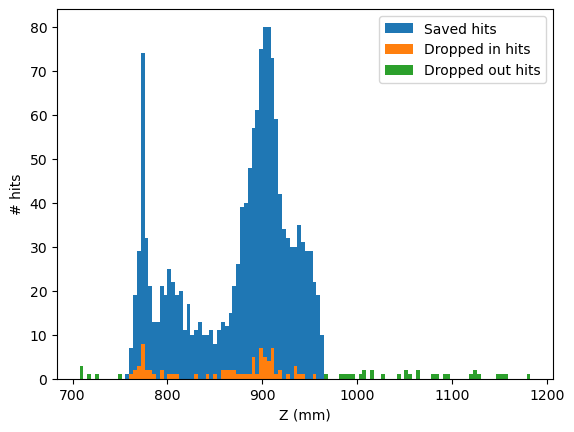

1.7004289070925898
3819 ldc4


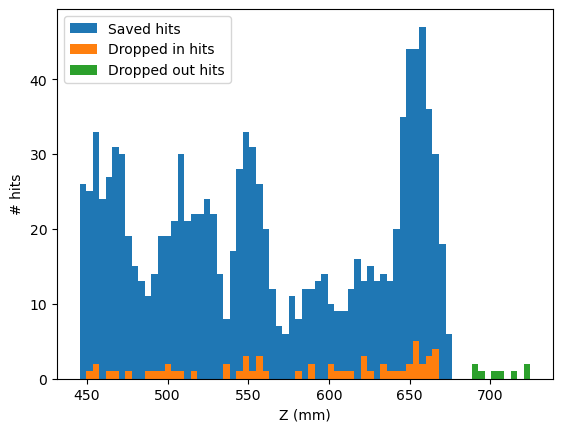

1.6247775850382915
4862 ldc4


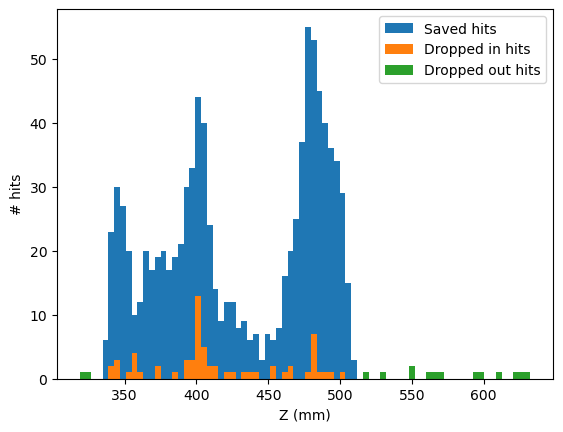

1.6250102841194083
7704 ldc4


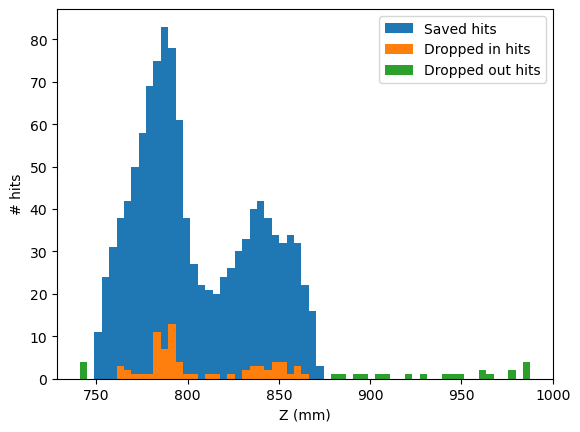

1.6726807024691157
10084 ldc4


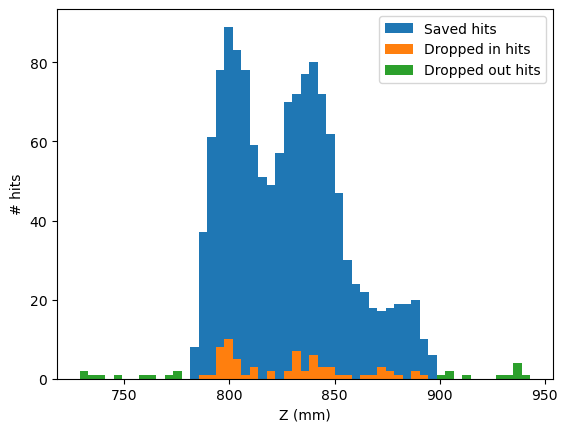

1.6795186672738827
12485 ldc4


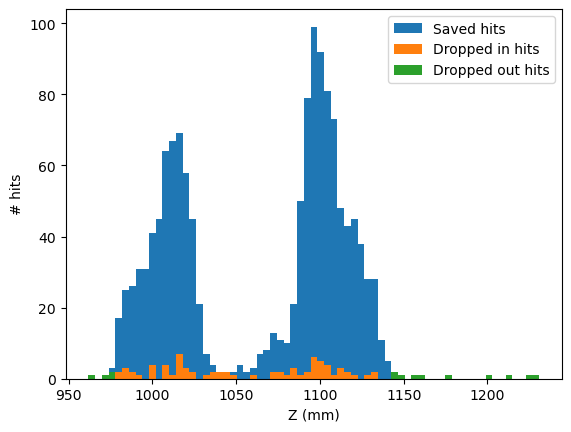

1.691489129240495
13577 ldc4


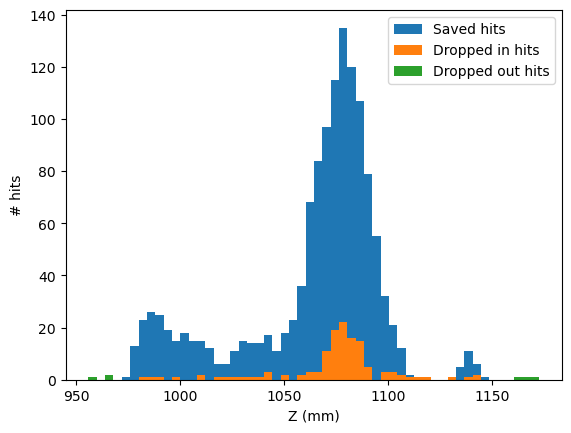

1.7598522420646834
13717 ldc4


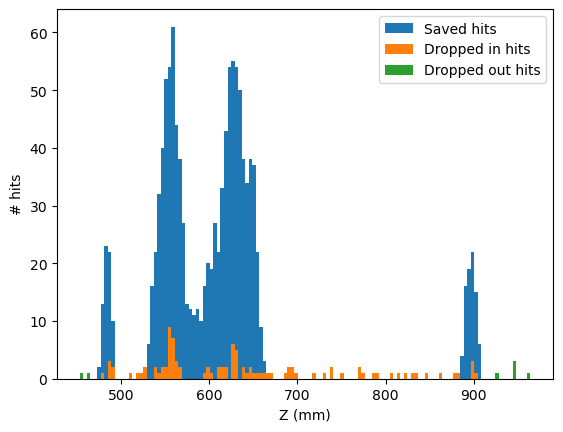

1.6701548359292047
13780 ldc4


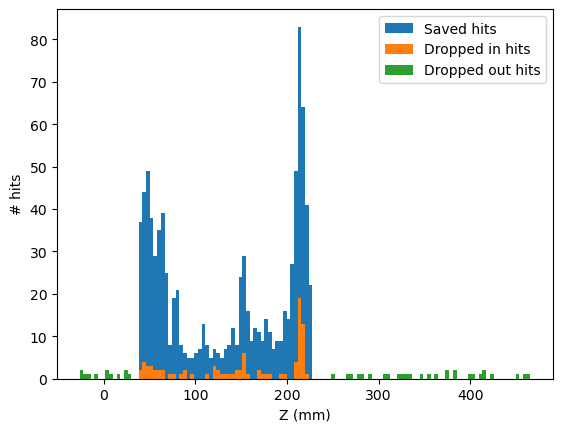

1.6748644801117551


In [81]:
for i, row in wf_sel[(wf_sel.total_energy > 1) & (wf_sel.total_energy < 2)].reset_index(drop=True).iterrows(): #.sort_values(['ldc_n', 'file_n'])
    print(row.event, row.ldc_n)
    f = glob.glob(data_path.format(run_number = run_number) + file_name.format(ldc_n = row.ldc_n, run_n = run_number, file_n = row.file_n))
    df = pd.read_hdf(f[0], 'RECO/Events')
    ev = df[df.event == row.event].copy()
    zmin, zmax = ev.Z.min(), ev.Z.max()
    zwidth = ev.Z.sort_values().drop_duplicates().diff().min()
    nbins = int((zmax - zmin) / 4) #hardcoded, but ~4 mm is the usual separation between zslices

    ev_final, ev_dropped, ev_nondrop = correct_and_drop(ev, corr_fun, dropper)
    nondrop_zmin, nondrop_zmax = ev_nondrop.Z.min(), ev_nondrop.Z.max()

     
    plt.hist(ev_nondrop.Z, nbins, (zmin, zmax), label = 'Saved hits')
    # plt.hist(ev_dropped.Z, nbins, (zmin, zmax), label = 'Dropped hits')
    plt.hist(ev_dropped[in_range(ev_dropped.Z, (nondrop_zmin, nondrop_zmax))].Z, nbins, (zmin, zmax), label = 'Dropped in hits')
    plt.hist(ev_dropped[(ev_dropped.Z < nondrop_zmin) | (ev_dropped.Z > nondrop_zmax)].Z, nbins, (zmin, zmax), label = 'Dropped out hits')
    plt.xlabel('Z (mm)')
    plt.ylabel('# hits')
    plt.legend()
    plt.show()
    print(ev.Ec.sum())
    # plt.hist(ev_nondrop.Z, nbins, (zmin, zmax), weights=ev_nondrop.E, label = 'Saved hits')
    # plt.hist(ev_dropped.Z, nbins, (zmin, zmax), weights=ev_dropped.E, label = 'Dropped hits')
    # plt.xlabel('Z (mm)')
    # plt.ylabel('E (pes)')
    # # plt.yscale('log')
    # plt.legend()
    # plt.show()
    # plt.hist(ev_nondrop.Z, nbins, (zmin, zmax), weights=ev_nondrop.Ec, label = 'Saved hits')
    # plt.hist(ev_dropped.Z, nbins, (zmin, zmax), weights=ev_dropped.Ec, label = 'Dropped hits')
    # plt.xlabel('Z (mm)')
    # plt.ylabel('Ec (MeV)')
    # # plt.yscale('log')
    # plt.legend()
    # plt.show()
    
    if i == 10:
        break

No handles with labels found to put in legend.


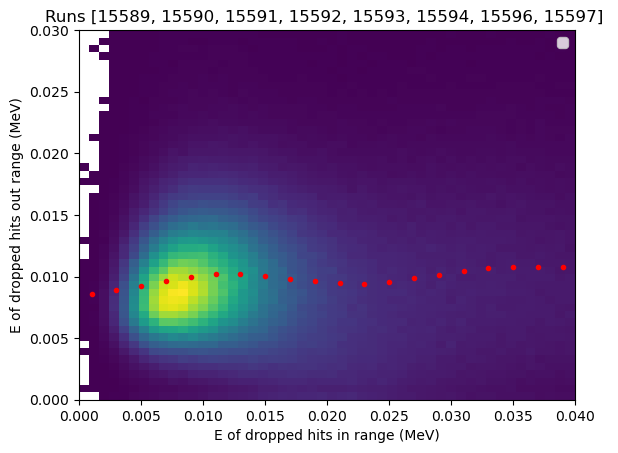

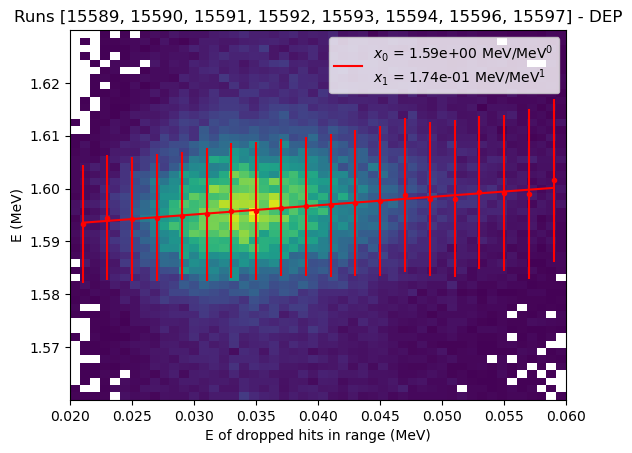

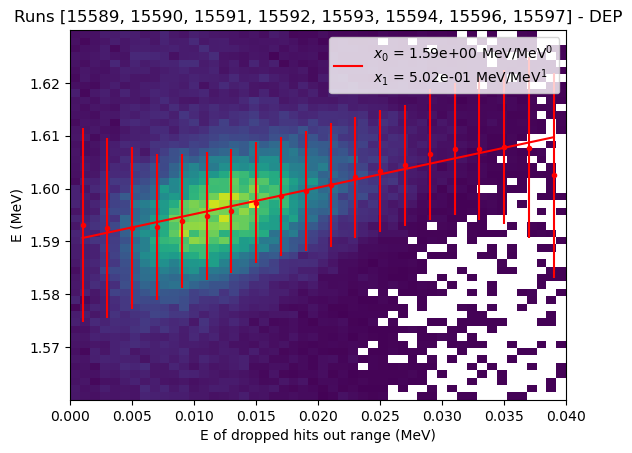

array([0.50224221, 1.59013817])

In [75]:
plot_profile(reco_summ, 'Ec_drop_in', 'Ec_drop_out', fitfun=None, initial_values=(1.67, 0), std = False, fitbins=20, plotbins=(50, 50), fitrange=((0, 0.04), (0, 0.03)), plotrange=((0, 0.04), (0, 0.03)), axlabel = ['E of dropped hits in range', 'E of dropped hits out range'], units = ['MeV', 'MeV'], title='Runs {} '.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Ec_drop_in', 'E_shifted', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=20, plotbins=(50, 50), fitrange=((0.02, 0.06), None), plotrange=((0.02, 0.06), None), axlabel = ['E of dropped hits in range', 'E'], units = ['MeV', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_profile(reco_summ[in_range(reco_summ.E_shifted, 1.56, 1.63)], 'Ec_drop_out', 'E_shifted', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=20, plotbins=(50, 50), fitrange=((0, 0.04), None), plotrange=((0, 0.04), None), axlabel = ['E of dropped hits out range', 'E'], units = ['MeV', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
